# Imports

In [154]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Helper functions

In [155]:
def det(X):
  return np.linalg.det(X)

def inv(X):
  return np.linalg.inv(X)

# Basis functions

In [156]:
def identity_bf(X):
  return X

def radial_bf(X, centers, lambdaval):
  d = X[:, np.newaxis] - centers[np.newaxis, :]
  y = np.exp(-0.5 * (d ** 2) / lambdaval)
  return y

def polynomial_bf(X, pow):
  return X ** pow

# Load and format data

In [157]:
full_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")

# Pick features and labels
# Scale down to achieve sufficient accuracy for radial bf's
X = full_data[["Area"]].values / 10000
concrete = full_data[["Concrete"]].values
mineral_wool = full_data[["Mineral_wool"]].values
metal = full_data[["Metal"]].values
glass = full_data[["Glass"]].values

X_tr, X_tst, y_tr, y_tst = train_test_split(X, concrete, test_size=0.2, random_state=42)

# Implement Bayesian linear regression

In [158]:
def BLR(X, y, alpha, beta, mu_0):

  N, F = X.shape

  # Posterior mean mu and covariance matrix S
  S_inv = beta * (X.T @ X) + alpha * np.identity(F)
  S = inv(S_inv)
  mu = S @ ((beta * X.T @ y).flatten() + alpha * mu_0)

  # Log-likelihood (Barber 18.1.19)
  d = (beta * X.T @ y).flatten() + alpha * mu_0
  
  log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d + np.log(det(2 * np.pi * S))
            + F * np.log(alpha) + N * np.log(beta) - N * np.log(2 * np.pi))
  #log_lik = -0.5 * np.log(det(2 * np.pi * S)) - 0.5 * y.T @ S_inv
  #log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d)

  return mu, S, log_lik

19088497.4119477


,Parameter,Value
0,alpha,0.1
1,beta,0.1
2,mu0,20.0


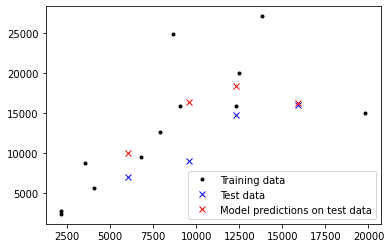

In [159]:
area_mu_0 = np.linspace(5, 20, 10)
alphas = np.linspace(0.1, 20, 100)
betas = np.linspace(0.1, 1, 100)
best_log_lik = -np.inf

centers = np.linspace(0.2, 2, 5)
lambdaval = 0.1
X_input = radial_bf(X_tr, centers, lambdaval)[:, 0, :]
X_test = radial_bf(X_tst, centers, lambdaval)[:, 0, :]

for area_mu in area_mu_0:
  for alpha in alphas:
    for beta in betas:

      mu_0 = area_mu
      post_mu, post_S, log_lik_candidate = BLR(
          X_input, y_tr, alpha, beta, mu_0)

      if log_lik_candidate > best_log_lik:
        best_alpha = alpha
        best_beta = beta
        best_log_lik = log_lik_candidate
        best_mu_0 = mu_0

best_mu, best_S, loglik = BLR(X_input, y_tr, best_alpha, best_beta, best_mu_0)

y_pred = X_test @ best_mu
mse_test = mean_squared_error(y_tst, y_pred)
print(mse_test)

X_tr = X_tr * 10000
X_tst = X_tst * 10000

params = pd.DataFrame({
  'Parameter': ['alpha', 'beta', 'mu0'],
  'Value': [best_alpha, best_beta, best_mu_0]
})
display(params)
fig = plt.figure()
plt.plot(X_tr, y_tr, '.k', label='Training data')
plt.plot(X_tst, y_tst, 'bx', label='Test data')
plt.plot(X_tst, y_pred, 'rx', label='Model predictions on test data')
plt.legend()
plt.show()
